# 1: Cài đặt thư viện và chuẩn bị môi trường

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')
!pip install ultralytics
from ultralytics import YOLO
import torch

# Kiểm tra xem đã nhận GPU chưa
if torch.cuda.is_available():
    print(f"Đã nhận GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Đang dùng CPU")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Đã nhận GPU: Tesla T4


# 2: Giải nén Dataset

In [2]:
import yaml

# 1. Giải nén dataset vào Colab để train nhanh hơn
!mkdir -p /content/datasets
!unzip -q /content/drive/MyDrive/waste_data.zip -d /content/datasets

# 2. Tìm vị trí thực sự của file data.yaml trên Drive
# Giả sử file của bạn tên là data.yaml nằm ở Drive
original_yaml = '/content/drive/MyDrive/data.yaml'

with open(original_yaml, 'r') as f:
    config = yaml.safe_load(f)

# 3. Tự động tìm thư mục chứa 'train' và 'val' sau khi giải nén
found_path = "/content/datasets"
for root, dirs, files in os.walk("/content/datasets"):
    if 'train' in dirs and 'val' in dirs:
        found_path = root
        break

# 4. Ghi file yaml mới vào ngay thư mục /content/ để YOLO luôn tìm thấy
config['path'] = found_path
config['train'] = 'train/images'
config['val'] = 'val/images'

with open('/content/data_ready.yaml', 'w') as f:
    yaml.dump(config, f)

print(f"✅ Đã tạo file cấu hình tại: /content/data_ready.yaml")
print(f"📂 Dataset chuẩn nằm tại: {found_path}")

✅ Đã tạo file cấu hình tại: /content/data_ready.yaml
📂 Dataset chuẩn nằm tại: /content/datasets/datasets


# 3: Tiến hành Training

In [1]:
from ultralytics import YOLO
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

# 1. Chọn model
model = YOLO('yolov8n.pt')

model.train(
    data='/content/data_ready.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    cache=False,
    workers=2,
    # ---------------------------------
    device=0,
    project='/content/drive/MyDrive/waste_project',
    name='train_fixed_v2',
    amp=True
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_ready.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_fixed_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd05a0f4620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

# 4: Kiểm tra chỉ số mAP@50 và Confusion Matrix

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1368.2±296.0 MB/s, size: 61.1 KB)
val: Scanning /content/datasets/datasets/val/labels.cache... 1436 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1436/1436 547.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 90/90 5.9it/s 15.2s
                   all       1436       2834      0.904       0.87      0.925      0.794
                   ALU        130        130      0.777      0.966       0.91      0.907
                 GLASS        118        118      0.813      0.941      0.952      0.949
                   PET        110        110      0.941      0.809      0.941      0.934
               Battery         80        270       0.92      0.915      0.956      0.758
              Medicine        500   

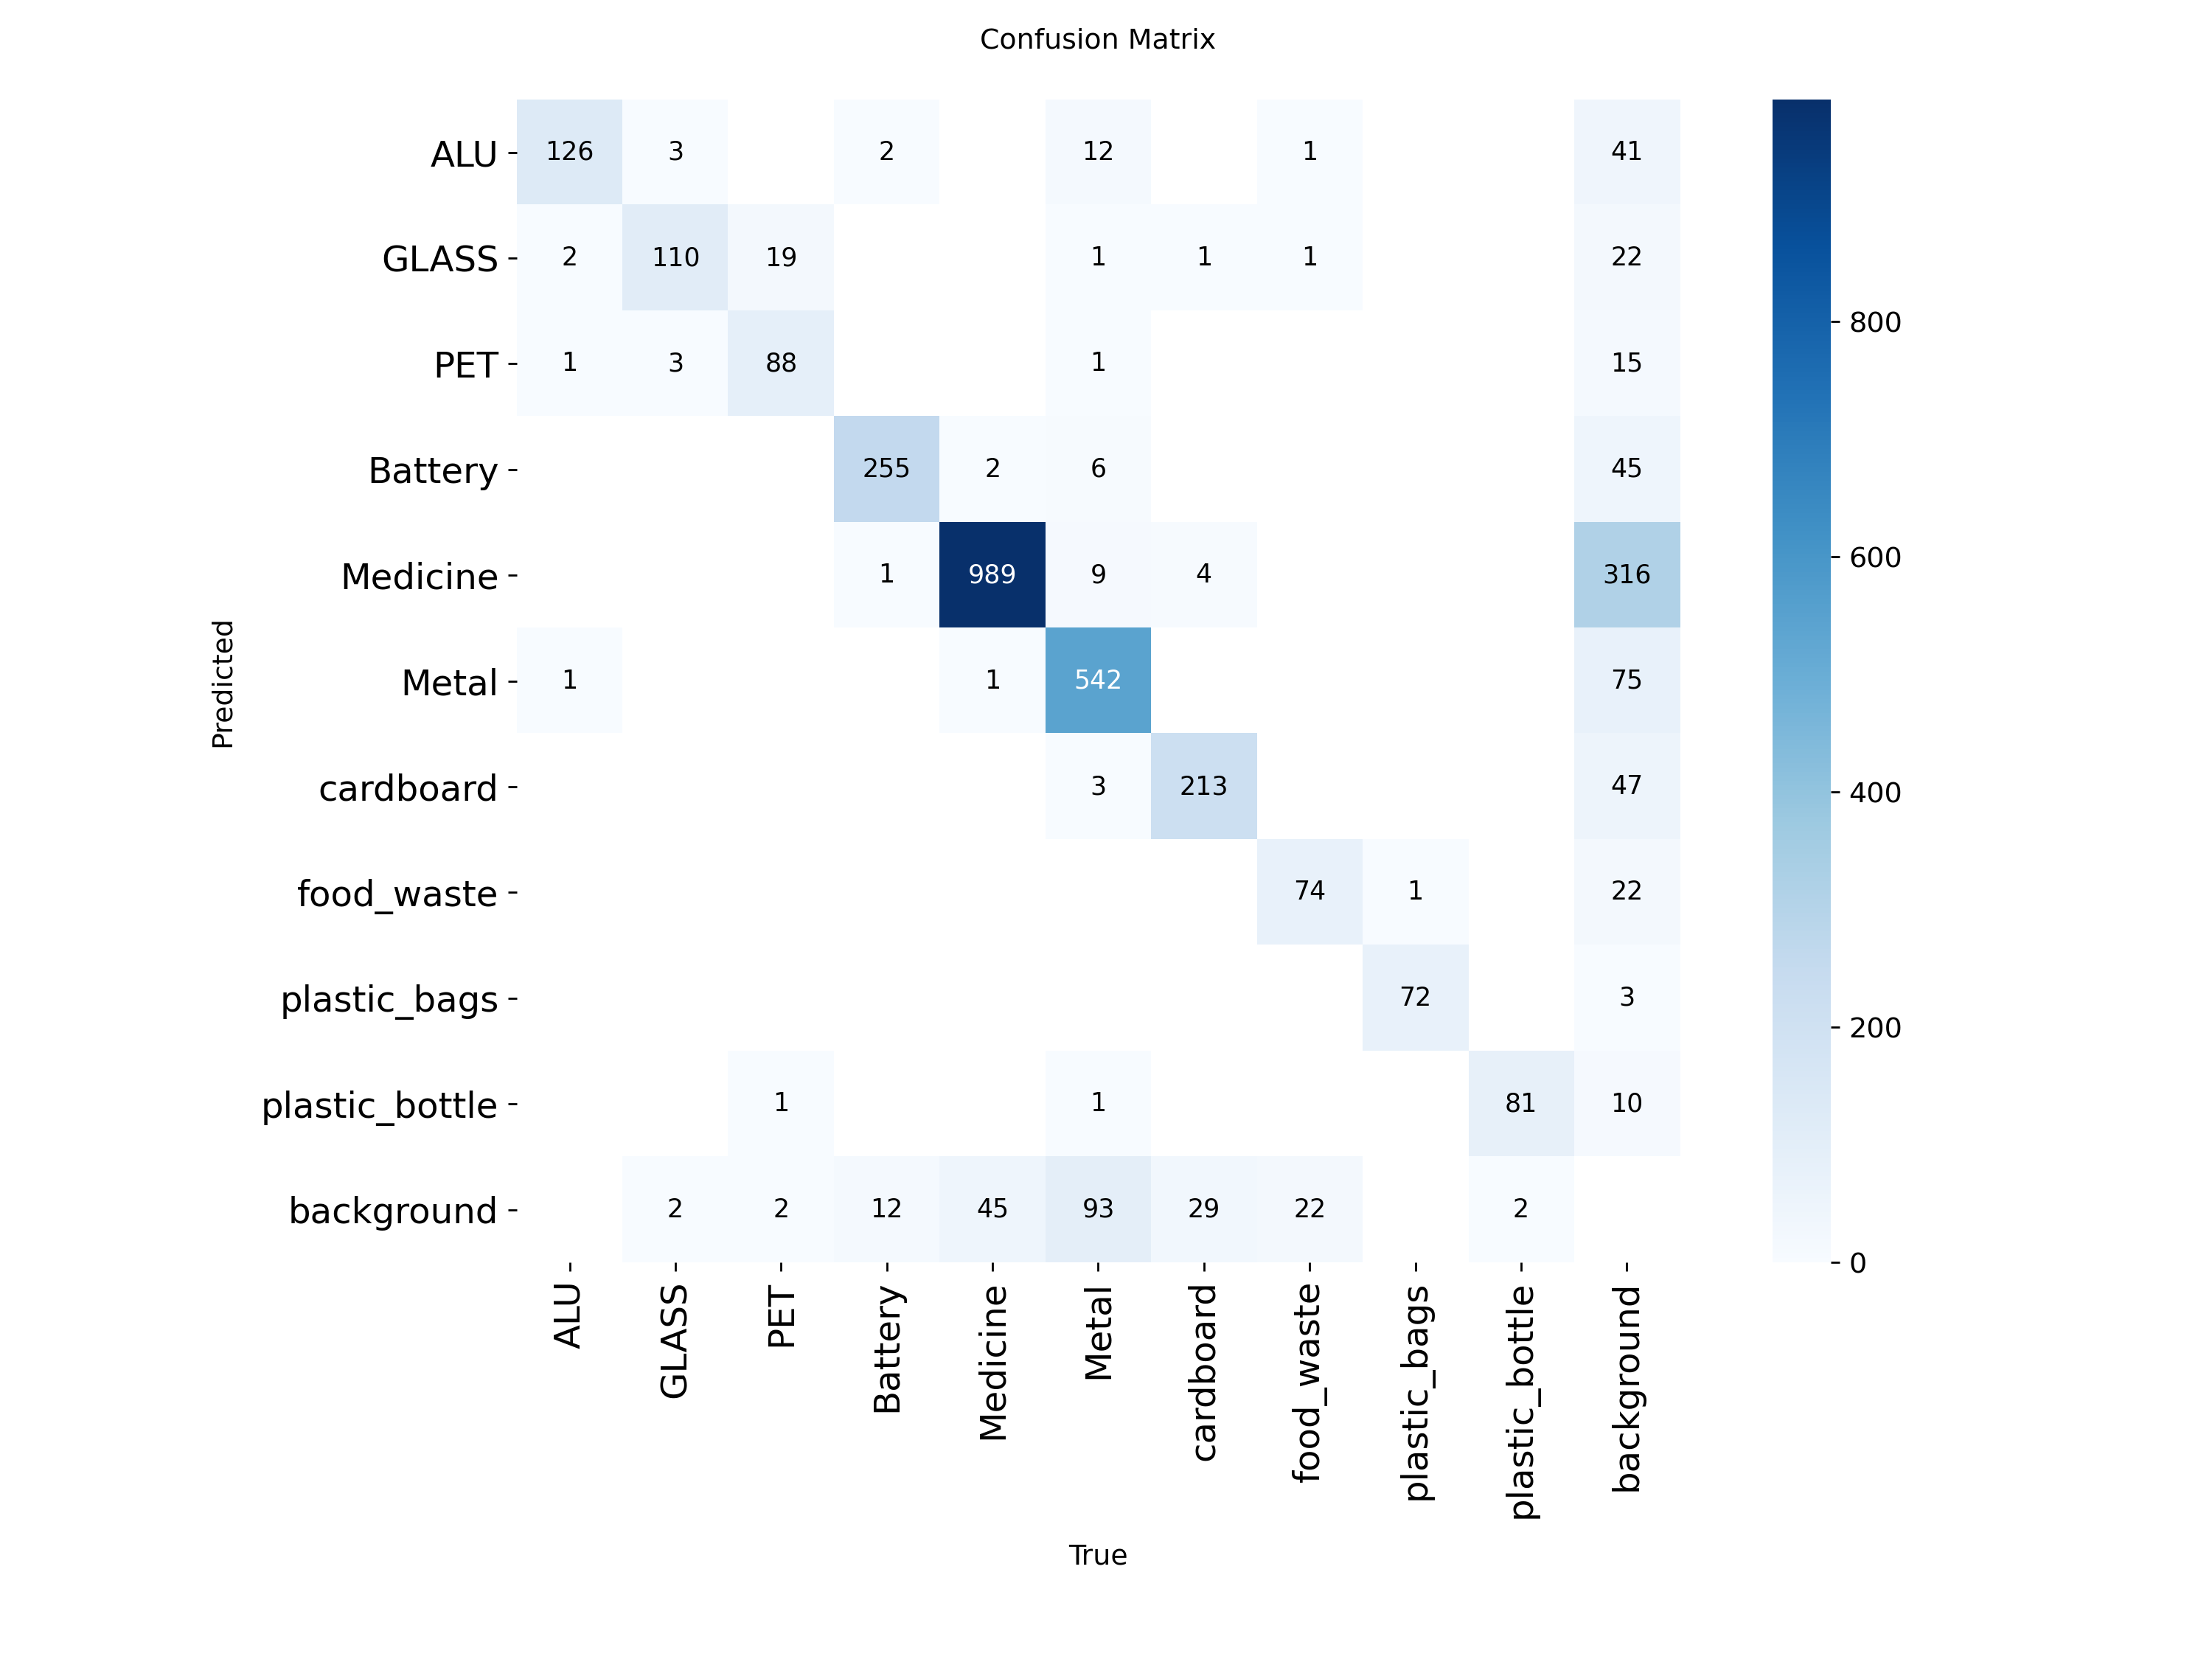

In [2]:
import os
from IPython.display import Image, display

metrics = model.val()

print("\n" + "="*40)
print(f"ĐỘ CHÍNH XÁC TỔNG QUÁT (ALL CLASSES):")
print("-" * 40)

# Truy cập trực tiếp qua thuộc tính để tránh KeyError
map50 = metrics.mean_results()[2] * 100 # Chỉ số thứ 3 là mAP50
precision = metrics.mean_results()[0] * 100
recall = metrics.mean_results()[1] * 100

print(f"✅ mAP@50 (Độ chính xác trung bình): {map50:.2f}%")
print(f"✅ Precision (Độ chuẩn xác): {precision:.2f}%")
print(f"✅ Recall (Độ bao phủ): {recall:.2f}%")
print("="*40)

# Hiển thị bảng chi tiết từng class từ log bạn vừa cung cấp

# Đường dẫn mặc định YOLO lưu khi chạy .val()
val_dir = metrics.save_dir

print("\n MA TRẬN NHẦM LẪN (CONFUSION MATRIX):")
conf_path = os.path.join(val_dir, 'confusion_matrix.png')

if os.path.exists(conf_path):
    display(Image(filename=conf_path, width=800))
else:
    print("Không tìm thấy file ảnh Confusion Matrix. Hãy kiểm tra thư mục:", val_dir)

# 5: Dự đoán và Map kết quả


image 1/1 /content/test_bottle_3.png: 640x640 1 PET, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

--- KẾT QUẢ PHÂN LOẠI ---
Phát hiện: pet plastic (98.3%)


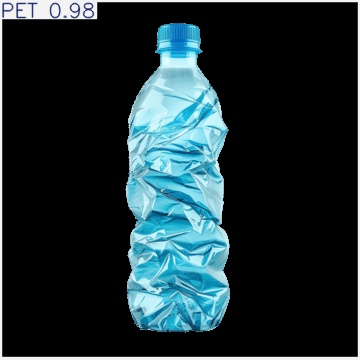

In [6]:
# Load model tốt nhất
EXP_PATH = '/content/drive/MyDrive/waste_project/train_fixed_v2'
best_model = YOLO(f'{EXP_PATH}/weights/best.pt')

# Bảng dịch 10 Class của bạn
waste_map = {
    'ALU': 'alunium',
    'GLASS': 'glass',
    'PET': 'pet plastic',
    'Battery': 'battery',
    'Medicine': 'medicine',
    'Metal': 'metal',
    'cardboard': 'cardboard',
    'food_waste': 'food waste',
    'plastic_bags': 'plastic bag',
    'plastic_bottle': 'plastic bottle'
}

# Thay đường dẫn ảnh bạn muốn test ở đây
TEST_IMAGE = '/content/test_bottle_3.png' # Hoặc một ảnh bất kỳ

res = best_model.predict(TEST_IMAGE, conf=0.3)

print("\n--- KẾT QUẢ PHÂN LOẠI ---")
for r in res:
    for box in r.boxes:
        eng_name = best_model.names[int(box.cls[0])]
        vn_name = waste_map.get(eng_name, eng_name)
        prob = float(box.conf[0]) * 100
        print(f"Phát hiện: {vn_name} ({prob:.1f}%)")

    # Hiển thị ảnh
    r.save(filename='out.jpg')
    display(Image(filename='out.jpg'))